# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

### Cargar Dataset

In [1]:
## Importar librerías y cargar el dataset
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# Cargar el dataset
df = pd.read_csv(
    "/datasets/novaretail_comportamiento_clientes_2024.csv"
)

El dataset se cargó correctamente

#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [3]:
# Primeras filas
display(df.head())

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


In [4]:
# Dimensiones
print("Dimensiones del dataset:", df.shape)
print("Número de filas:", df.shape[0])
print("Número de columnas:", df.shape[1])

# Nombres de columnas
print("\nColumnas:")
print(df.columns.tolist())

# Estructura y tipos
print("\nInformación general:")
df.info()

# Valores faltantes
resumen_faltantes = pd.DataFrame({
    "valores_faltantes": df.isna().sum(),
    "porcentaje_faltante": (
        df.isna().mean() * 100
    ).round(2)
})

print("\nValores faltantes:")
display(resumen_faltantes)

Dimensiones del dataset: (15000, 12)
Número de filas: 15000
Número de columnas: 12

Columnas:
['id_cliente', 'edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 'gasto_publicidad_dirigida', 'satisfaccion', 'miembro_premium', 'abandono', 'tipo_dispositivo', 'region', 'ingreso_anual']

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono         

,valores_faltantes,porcentaje_faltante
id_cliente,0,0.0
edad,0,0.0
nivel_ingreso,0,0.0
visitas_mes,0,0.0
compras_mes,0,0.0
gasto_publicidad_dirigida,0,0.0
satisfaccion,0,0.0
miembro_premium,0,0.0
abandono,0,0.0
tipo_dispositivo,0,0.0


In [5]:
# Duplicados
print(
    "Filas duplicadas:",
    df.duplicated().sum()
)

print(
    "ID de clientes duplicados:",
    df["id_cliente"].duplicated().sum()
)

Filas duplicadas: 0
ID de clientes duplicados: 0


In [6]:
# Columnas numéricas
columnas_numericas = [
    "edad",
    "nivel_ingreso",
    "visitas_mes",
    "compras_mes",
    "gasto_publicidad_dirigida",
    "satisfaccion",
    "ingreso_anual"
]

# Resumen estadístico
print("\nResumen de variables numéricas:")
display(df[columnas_numericas].describe())

# Rangos
rangos = pd.DataFrame({
    "mínimo": df[columnas_numericas].min(),
    "máximo": df[columnas_numericas].max()
})

print("\nRangos generales:")
display(rangos)


Resumen de variables numéricas:


,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,244.690000



Rangos generales:


,mínimo,máximo
edad,18.0,75.00
nivel_ingreso,8000.0,74790.84
visitas_mes,1.0,25.00
compras_mes,0.0,8.00
gasto_publicidad_dirigida,0.0,75.51
satisfaccion,1.0,5.00
ingreso_anual,0.0,244.69


In [7]:
# Validaciones
print("Edades negativas:", (df["edad"] < 0).sum())

print(
    "Ingresos estimados negativos:",
    (df["nivel_ingreso"] < 0).sum()
)

print(
    "Visitas negativas:",
    (df["visitas_mes"] < 0).sum()
)

print(
    "Compras negativas:",
    (df["compras_mes"] < 0).sum()
)

print(
    "Gasto publicitario negativo:",
    (df["gasto_publicidad_dirigida"] < 0).sum()
)

print(
    "Satisfacción fuera de rango:",
    (
        (df["satisfaccion"] < 1)
        | (df["satisfaccion"] > 5)
    ).sum()
)

print(
    "Ingreso anual negativo:",
    (df["ingreso_anual"] < 0).sum()
)


Edades negativas: 0
Ingresos estimados negativos: 0
Visitas negativas: 0
Compras negativas: 0
Gasto publicitario negativo: 0
Satisfacción fuera de rango: 0
Ingreso anual negativo: 0


In [8]:
# Variables binarias
for columna in ["miembro_premium", "abandono"]:
    print(f"\nDistribución de {columna}:")
    print(df[columna].value_counts(dropna=False))


Distribución de miembro_premium:
0    12911
1     2089
Name: miembro_premium, dtype: int64

Distribución de abandono:
0    12739
1     2261
Name: abandono, dtype: int64


In [9]:
# Variables categóricas
for columna in ["tipo_dispositivo", "region"]:
    print(f"\nDistribución de {columna}:")
    print(df[columna].value_counts(dropna=False))


Distribución de tipo_dispositivo:
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64

Distribución de region:
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64


#### Exploración inicial de los datos ###

Estos códigos permiten evaluar la estructura, integridad y consistencia básica del dataset antes de iniciar el análisis correlacional. Todavía no permiten identificar qué variables explican o están asociadas con ingreso_anual; su función es comprobar que los datos sean adecuados para ese análisis.

1. Estructura del conjunto de datos. Con base en la descripción del proyecto, se espera confirmar que el dataset contiene:
15,000 registros, cada uno correspondiente a un cliente.
12 columnas con información demográfica, conductual, comercial y económica.
Una variable objetivo: ingreso_anual.
Un identificador: id_cliente.
Variables numéricas, binarias y categóricas que deberán analizarse con métodos distintos.
La columna id_cliente debe conservarse para identificar registros, pero no debe incluirse en las correlaciones, ya que sus valores no representan una característica del cliente.

2. Tipos de datos. La ejecución de df.info() permite comprobar que:
edad, nivel_ingreso, visitas_mes, compras_mes, gasto_publicidad_dirigida, satisfaccion e ingreso_anual sean variables numéricas.
miembro_premium y abandono estén codificadas como variables binarias.
tipo_dispositivo y region sean variables categóricas.
id_cliente sea una variable de texto o identificador. Si los tipos coinciden con esta estructura, no será necesario convertir columnas antes del análisis.

3. Valores faltantes. La tabla resumen_faltantes muestra la cantidad y porcentaje de ausencias por columna.
Si todos los resultados son cero, la conclusión es: No se identificaron valores faltantes en el dataset. Por tanto, no será necesario aplicar procedimientos de eliminación o imputación antes del análisis correlacional. Si alguna columna presenta ausencias, será necesario documentar su magnitud y decidir cómo tratarlas antes de continuar.

4. Registros duplicados. Las instrucciones revisan dos situaciones diferentes:
Filas completamente duplicadas.
Clientes con id_cliente repetido.
Ambos conteos son cero:

No se detectaron filas duplicadas ni identificadores de clientes repetidos. Cada registro puede considerarse una observación única dentro del dataset. Si existen identificadores duplicados, será necesario investigar si corresponden a errores o a varios registros legítimos del mismo cliente.

5. Distribución y rangos de las variables numéricas. describe() permite conocer:
Media y mediana aproximada.
Dispersión de los datos.
Valores mínimos y máximos.
Cuartiles.
Posibles valores extremos.

La tabla de rangos y las validaciones comprueban que no existan:
+ Edades negativas.
+ Ingresos negativos.
+ Visitas o compras negativas.
+ Gastos publicitarios negativos.
+ Valores de satisfacción fuera de la escala de 1 a 5.
+ Ingresos anuales negativos.
+ Si todos estos conteos son cero: Las variables numéricas presentan rangos lógicamente válidos. No se detectaron valores negativos en variables que no deberían contenerlos ni puntuaciones de satisfacción fuera de la escala establecida. Esto demuestra consistencia básica, pero no descarta la presencia de outliers válidos. Estos deberán examinarse posteriormente mediante histogramas, boxplots y scatterplots.

6. Variables binarias. La distribución de miembro_premium y abandono permite verificar:
+ Que únicamente contengan los valores 0 y 1.
+ El número de clientes en cada grupo.
+ Si existe un fuerte desequilibrio entre las categorías.

Una conclusión adecuada sería: Las variables miembro_premium y abandono están codificadas como variables binarias. Su distribución permitirá comparar el ingreso anual entre clientes premium y no premium, así como entre clientes que abandonaron y quienes permanecieron en la plataforma. Estas variables podrán analizarse frente a ingreso_anual mediante correlación punto-biserial.

7. Variables categóricas. Los conteos de tipo_dispositivo y region permiten comprobar:
Que las categorías tengan nombres consistentes.
Que no existan variantes por errores de escritura.
Que todos los grupos estén suficientemente representados.

Conclusión de la exploración inicial

El dataset de NovaRetail+ se cargó correctamente y contiene 15,000 registros y 12 columnas. Cada fila representa un cliente y las variables incluyen información demográfica, conductual, comercial, de segmentación y de valor económico.
Los tipos de datos son consistentes con la naturaleza de las variables. Las características de comportamiento e ingreso son numéricas; `miembro_premium` y `abandono` son variables binarias; mientras que `tipo_dispositivo` y `region` son categóricas.
No se identificaron valores faltantes, filas duplicadas ni identificadores de clientes repetidos. Tampoco se detectaron valores negativos en variables que deberían ser no negativas ni puntuaciones de satisfacción fuera de la escala de 1 a 5.
La variable `id_cliente` se conservará únicamente como identificador y será excluida de los cálculos de correlación. La métrica principal será `ingreso_anual`, que se analizará en relación con las variables demográficas y de comportamiento.
En términos generales, el dataset presenta una estructura consistente y se encuentra en condiciones adecuadas para continuar con la exploración visual, el análisis de correlaciones y la identificación de posibles drivers asociados con el ingreso anual.

## Sección 2 - Preparar datos y documentar supuestos

In [10]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [11]:
# Estadísticas descriptivas de variables numéricas
# Seleccionar columnas numéricas
columnas_numericas = [
    "edad",
    "nivel_ingreso",
    "visitas_mes",
    "compras_mes",
    "gasto_publicidad_dirigida",
    "satisfaccion",
    "ingreso_anual"
]

# Mostrar resumen estadístico
df[columnas_numericas].describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,244.690000


✍️ **Comentario**: Análisis de las variables numéricas

+ El conjunto contiene 15,000 registros completos en todas las variables, por lo que no se observan valores faltantes en estas columnas.
+ Edad: los clientes tienen una edad promedio de 38.3 años y la mitad se concentra entre 30 y 46 años. El mercado está compuesto principalmente por adultos de edad media, aunque incluye personas de 18 a 75 años.
+ Nivel de ingreso: el ingreso promedio es de 30,019.70, prácticamente igual a la mediana de 30,023.75. Esto sugiere una distribución relativamente equilibrada, aunque el máximo de 74,790.84 indica la presencia de clientes con ingresos considerablemente altos.
+ Visitas mensuales: los clientes realizan, en promedio, 10 visitas al mes. El 50% registra entre 8 y 12 visitas, por lo que la frecuencia de interacción es relativamente estable.
+ Compras mensuales: el promedio es de 1.21 compras, mientras que la mediana es de una compra. Al menos el 25% de los clientes no realiza ninguna compra, pese a visitar el negocio o plataforma. Esto muestra una oportunidad importante para mejorar la conversión de visitas en compras.
+ Gasto en publicidad dirigida: el gasto promedio es de 20.15 por cliente y la mitad de los valores se encuentra entre 12.31 y 27.29. El máximo de 75.51 sugiere que algunos clientes reciben una inversión publicitaria mucho mayor.
+ Satisfacción: la calificación promedio es de 3.60 sobre 5 y el 50% de las evaluaciones se encuentra entre 3.1 y 4.1. La percepción general es moderadamente favorable, pero aún existe margen para mejorar la experiencia del cliente.
+ Ingreso anual: el promedio es de 36.59, pero la mediana es menor, con 30.71, y el máximo alcanza 244.69. Además, por lo menos el 25% registra un ingreso anual igual a cero. La gran desviación estándar de 34.48 indica una distribución muy dispersa y sesgada hacia valores elevados.

Conclusión general
El cliente típico tiene aproximadamente 38 años, un nivel de ingreso cercano a 30,000, realiza 10 visitas mensuales, pero solamente concreta una compra al mes. El hallazgo más relevante es la diferencia entre la frecuencia de visitas y el número de compras, lo que sugiere una baja conversión comercial.
La empresa debería analizar a los clientes que visitan con frecuencia pero no compran, evaluar si el gasto publicitario realmente incrementa las compras y diseñar promociones específicas para el segmento sin compras. También conviene estudiar por separado a los clientes con ingresos anuales muy altos, porque podrían representar un grupo de alto valor comercial.

#### Explorar variables binarias

In [12]:
# Verificar que cada columna tenga únicamente dos valores posibles
columnas_binarias = [
    "miembro_premium",
    "abandono"
]

for columna in columnas_binarias:
    print(f"\nValores de {columna}:")
    print(df[columna].value_counts(dropna=False))


Valores de miembro_premium:
0    12911
1     2089
Name: miembro_premium, dtype: int64

Valores de abandono:
0    12739
1     2261
Name: abandono, dtype: int64


✍️ **Comentario**: Conclusiones sobre las variables binarias

Membresía premium: solamente 2,089 clientes (13.93%) son miembros premium, mientras que 12,911 (86.07%) no pertenecen al programa. La membresía tiene una penetración relativamente baja, por lo que existe una oportunidad para incrementar las conversiones mediante beneficios, promociones o campañas segmentadas.

Abandono: un total de 2,261 clientes (15.07%) abandonó la empresa, mientras que 12,739 (84.93%) permanecieron. Esto significa que aproximadamente 15 de cada 100 clientes se pierden.

Conclusión general
La empresa conserva a la mayoría de sus clientes, pero la tasa de abandono del 15.07% representa un grupo considerable: más de 2,200 clientes. Al mismo tiempo, menos de uno de cada siete clientes cuenta con una membresía premium.

#### Explorar variables categóricas

In [13]:
# Verificar el número de valores únicos por variable categórica
columnas_categoricas = [
    "tipo_dispositivo",
    "region"
]

for columna in columnas_categoricas:
    print(f"\nDistribución de {columna}:")
    print(df[columna].value_counts(dropna=False))


Distribución de tipo_dispositivo:
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64

Distribución de region:
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64


In [14]:
# Explorar variables categóricas y cómo se distribuyen
# Variables categóricas
columnas_categoricas = [
    "tipo_dispositivo",
    "region"
]

# Explorar distribución de cada variable categórica
for columna in columnas_categoricas:
    print(f"\nDistribución de {columna}:")
    
    frecuencias = df[columna].value_counts(dropna=False)
    
    porcentajes = (
        df[columna]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .round(2)
    )
    
    resumen = pd.DataFrame({
        "frecuencia": frecuencias,
        "porcentaje": porcentajes
    })
    
    display(resumen)


Distribución de tipo_dispositivo:


,frecuencia,porcentaje
móvil,9818,65.45
escritorio,3720,24.80
tablet,1462,9.75



Distribución de region:


,frecuencia,porcentaje
norte,4395,29.30
oeste,3810,25.40
sur,3726,24.84
este,3069,20.46


✍️ **Comentario**: Conclusiones sobre las variables categóricas

Tipo de dispositivo
+ El móvil domina claramente con 9,818 clientes (65.45%), es decir, aproximadamente dos de cada tres usuarios.
+ El escritorio ocupa el segundo lugar con 3,720 usuarios (24.80%).

La tablet presenta la menor participación, con 1,462 usuarios (9.75%).
Esto indica que la experiencia digital y las campañas comerciales deberían diseñarse prioritariamente para dispositivos móviles. Sin embargo, el escritorio todavía representa casi una cuarta parte de los usuarios, por lo que no debe descuidarse. La tablet podría recibir menor prioridad.

Región
+ La región norte concentra la mayor proporción: 4,395 clientes (29.30%).
+ Le siguen oeste (25.40%) y sur (24.84%), con participaciones muy similares.
+ La región este registra la menor presencia, con 3,069 clientes (20.46%).

La distribución regional es relativamente equilibrada, ya que ninguna región concentra más del 30% de los clientes. El norte constituye el mercado principal, mientras que el este podría representar una oportunidad de crecimiento, aunque primero habría que determinar si su menor participación se debe a menor demanda, cobertura limitada o menor inversión comercial.

Conclusión general. 
La mayoría de los clientes utiliza dispositivos móviles (65.45%), por lo que la empresa debe priorizar la experiencia y publicidad para celular. Por región, los clientes están relativamente bien distribuidos, aunque el norte concentra la mayor proporción (29.30%) y el este la menor (20.46%). Esto sugiere mantener una estrategia nacional, reforzando las oportunidades de crecimiento en la región este.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

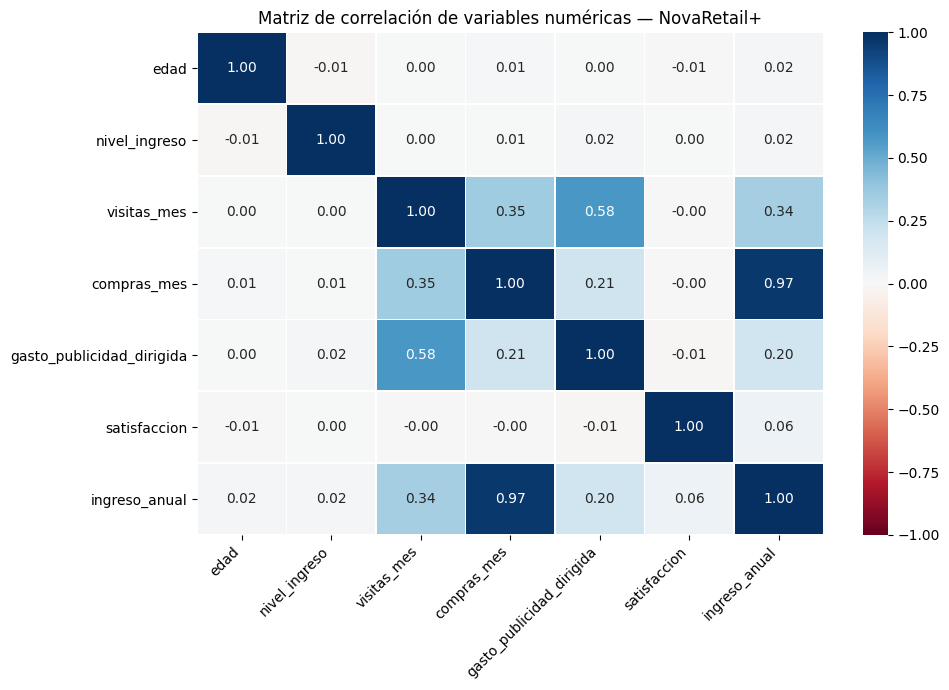

In [15]:
# Visualizar la matriz de correlación para identificar relaciones
# Seleccionar las variables numéricas relevantes
columnas_correlacion = [
    "edad",
    "nivel_ingreso",
    "visitas_mes",
    "compras_mes",
    "gasto_publicidad_dirigida",
    "satisfaccion",
    "ingreso_anual"
]

# Calcular la matriz de correlación de Pearson
matriz_correlacion = df[columnas_correlacion].corr(
    method="pearson"
)

# Establecer el tamaño de la figura
plt.figure(figsize=(10, 7))

# Crear el mapa de calor
sns.heatmap(
    matriz_correlacion,
    annot=True,
    cmap="RdBu",
    center=0,
    vmin=-1,
    vmax=1,
    fmt=".2f",
    linewidths=0.5
)

# Personalizar la gráfica
plt.title(
    "Matriz de correlación de variables numéricas — NovaRetail+"
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

# Mostrar la gráfica
plt.show()

✍️ **Comentario**:
La matriz permite identificar las siguientes relaciones:
+ Compras mensuales e ingreso anual (r = 0.97): presentan una correlación positiva muy fuerte. Los clientes que realizan más compras generan mayores ingresos anuales. Es la relación más importante del análisis.
+ Visitas mensuales y gasto en publicidad dirigida (r = 0.58): existe una correlación positiva moderada. Una mayor inversión publicitaria se relaciona con más visitas, aunque no se puede afirmar que sea su causa.
+ Visitas y compras mensuales (r = 0.35): la relación es positiva, pero débil a moderada. Más visitas tienden a relacionarse con más compras, aunque muchas visitas no necesariamente terminan en una compra.
+ Visitas mensuales e ingreso anual (r = 0.34): existe una relación positiva moderada-baja. Los clientes que visitan más tienden a generar mayores ingresos.
+ Gasto publicitario e ingreso anual (r = 0.20) y gasto publicitario y compras (r = 0.21): ambas relaciones son débiles. La publicidad parece atraer visitas, pero su relación directa con compras e ingresos es limitada.
+ Satisfacción e ingreso anual (r = 0.06): la relación es prácticamente inexistente. En estos datos, una mayor satisfacción no se traduce claramente en mayores ingresos.
+ Edad y nivel de ingreso: muestran correlaciones cercanas a cero con las demás variables. Por sí solas, no parecen explicar el comportamiento de compra, las visitas ni el ingreso anual.

Conclusión concreta
El número de compras mensuales es la variable más relacionada con el ingreso anual. La publicidad se asocia principalmente con un aumento de visitas, pero mucho menos con las compras. Por ello, NovaRetail+ debería enfocarse en convertir las visitas generadas por la publicidad en compras, más que limitarse a incrementar el tráfico. Estas correlaciones muestran asociaciones, no relaciones de causa y efecto.

### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
  - Explica por qué.

In [16]:
# Identioficar variables moderadas y fuertes
from itertools import combinations

# Variables numéricas relevantes
columnas_correlacion = [
    "edad",
    "nivel_ingreso",
    "visitas_mes",
    "compras_mes",
    "gasto_publicidad_dirigida",
    "satisfaccion",
    "ingreso_anual"
]

# Calcular la matriz de correlación de Pearson
matriz_correlacion = df[columnas_correlacion].corr(
    method="pearson"
)

# Guardar los pares con correlación moderada o fuerte
pares_relevantes = []

for columna_1, columna_2 in combinations(columnas_correlacion, 2):
    correlacion = matriz_correlacion.loc[
        columna_1,
        columna_2
    ]

    if abs(correlacion) >= 0.50:
        pares_relevantes.append(
            (columna_1, columna_2, correlacion)
        )

# Mostrar los pares identificados
print("Pares con correlación moderada o fuerte:")

for columna_1, columna_2, correlacion in pares_relevantes:
    print(
        f"{columna_1} vs {columna_2}: "
        f"{correlacion:.2f}"
    )

Pares con correlación moderada o fuerte:
visitas_mes vs gasto_publicidad_dirigida: 0.58
compras_mes vs ingreso_anual: 0.97


### Scatterplot para pares clave

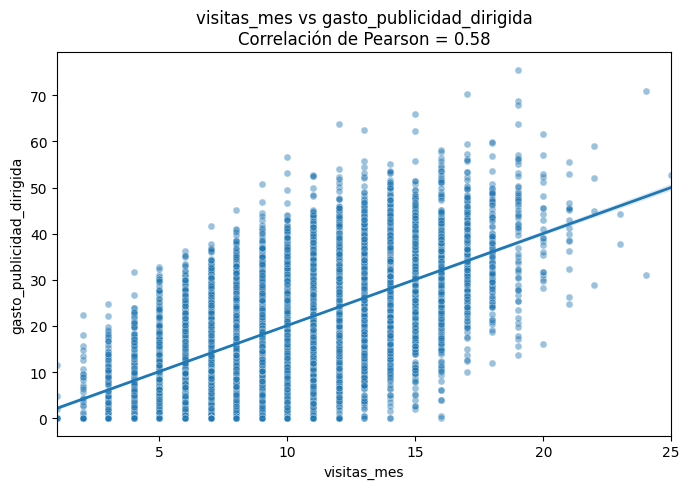

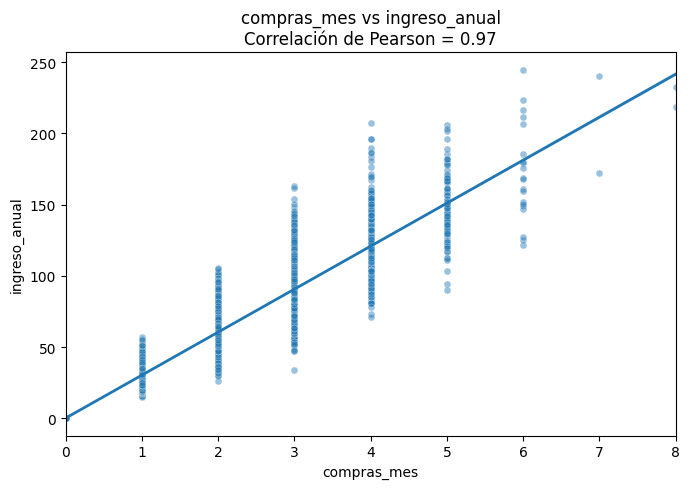

In [17]:
# Visualizar pares de variables con relaciones moderadas o fuertes
if len(pares_relevantes) == 0:
    print(
        "No se identificaron relaciones moderadas o fuertes."
    )

else:
    for columna_1, columna_2, correlacion in pares_relevantes:
        plt.figure(figsize=(7, 5))

        # Puntos
        sns.scatterplot(
            data=df,
            x=columna_1,
            y=columna_2,
            alpha=0.45,
            s=25
        )

        # Línea de tendencia
        sns.regplot(
            data=df,
            x=columna_1,
            y=columna_2,
            scatter=False,
            line_kws={"linewidth": 2}
        )

        plt.title(
            f"{columna_1} vs {columna_2}\n"
            f"Correlación de Pearson = {correlacion:.2f}"
        )

        plt.xlabel(columna_1)
        plt.ylabel(columna_2)
        plt.tight_layout()
        plt.show()

✍️ **Comentario**:
### Interpretación de los scatterplots

Los scatterplots permiten validar visualmente las relaciones moderadas o fuertes identificadas en la matriz de correlación. Una nube de puntos con una tendencia ascendente indica una relación positiva: cuando una variable aumenta, la otra también tiende a aumentar. Una tendencia descendente representa una relación negativa. Cuando los puntos se encuentran muy dispersos alrededor de la línea de tendencia, la relación es menos consistente. Los gráficos también permiten detectar valores atípicos, agrupamientos y posibles relaciones no lineales que podrían no quedar completamente representadas por el coeficiente de Pearson. Estas asociaciones no deben interpretarse como relaciones causales.

+ Visitas mensuales y gasto en publicidad (r = 0.58): existe una relación positiva moderada. Los clientes con mayor gasto publicitario dirigido tienden a realizar más visitas, aunque la dispersión indica que la publicidad no explica por sí sola su comportamiento.
+ Compras mensuales e ingreso anual (r = 0.97): existe una relación positiva muy fuerte y casi lineal. A medida que aumentan las compras mensuales, el ingreso anual generado por el cliente crece claramente.

Conclusión
La publicidad dirigida se relaciona principalmente con el aumento de visitas, pero su efecto es variable. En cambio, el número de compras mensuales es el mejor indicador del ingreso anual. Por ello, NovaRetail+ debería enfocarse en convertir las visitas generadas por la publicidad en compras efectivas. Estos resultados muestran asociación, no causalidad.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [18]:
# Calcular correlación entre variables relevantes
columnas_numericas = [
    "edad",
    "nivel_ingreso",
    "visitas_mes",
    "compras_mes",
    "gasto_publicidad_dirigida",
    "satisfaccion",
    "ingreso_anual"
]

# Matriz de correlación de Pearson
corr_pearson = df[columnas_numericas].corr(
    method="pearson"
)

# Matriz de correlación de Spearman
corr_spearman = df[columnas_numericas].corr(
    method="spearman"
)

print("Matriz de correlación de Pearson:")
display(corr_pearson)

print("Matriz de correlación de Spearman:")
display(corr_spearman)

Matriz de correlación de Pearson:


,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
edad,1.000000,-0.009003,0.004998,0.014971,0.000062,-0.006963,0.017496
nivel_ingreso,-0.009003,1.000000,0.001060,0.007309,0.016834,0.002301,0.017446
visitas_mes,0.004998,0.001060,1.000000,0.353844,0.578947,-0.003179,0.337147
compras_mes,0.014971,0.007309,0.353844,1.000000,0.207528,-0.003542,0.967149
gasto_publicidad_dirigida,0.000062,0.016834,0.578947,0.207528,1.000000,-0.013175,0.197483
satisfaccion,-0.006963,0.002301,-0.003179,-0.003542,-0.013175,1.000000,0.056171
ingreso_anual,0.017496,0.017446,0.337147,0.967149,0.197483,0.056171,1.000000


Matriz de correlación de Spearman:


,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
edad,1.000000,-0.007775,0.005205,0.015630,0.002869,-0.007590,0.016097
nivel_ingreso,-0.007775,1.000000,0.001420,0.009004,0.015393,0.005243,0.025017
visitas_mes,0.005205,0.001420,1.000000,0.332943,0.559267,-0.001305,0.320954
compras_mes,0.015630,0.009004,0.332943,1.000000,0.192511,-0.002006,0.967482
gasto_publicidad_dirigida,0.002869,0.015393,0.559267,0.192511,1.000000,-0.012612,0.184999
satisfaccion,-0.007590,0.005243,-0.001305,-0.002006,-0.012612,1.000000,0.060834
ingreso_anual,0.016097,0.025017,0.320954,0.967482,0.184999,0.060834,1.000000


✍️ **Comentario**: ### Comparación entre Pearson y Spearman

Pearson mide relaciones **lineales**, mientras que Spearman evalúa relaciones **monótonas** usando rangos y es menos sensible a valores extremos. Ambas matrices presentan resultados muy similares.

| Relación                         | Pearson | Spearman | Interpretación            |
| -------------------------------- | ------: | -------: | ------------------------- |
| Compras–ingreso anual            |   0.967 |    0.967 | Positiva muy fuerte       |
| Visitas–gasto publicitario       |   0.579 |    0.559 | Positiva moderada         |
| Visitas–compras                  |   0.354 |    0.333 | Positiva débil-moderada   |
| Visitas–ingreso anual            |   0.337 |    0.321 | Positiva débil-moderada   |
| Compras–gasto publicitario       |   0.208 |    0.193 | Positiva débil            |
| Gasto publicitario–ingreso anual |   0.197 |    0.185 | Positiva débil            |
| Satisfacción–ingreso anual       |   0.056 |    0.061 | Prácticamente inexistente |

### Principales resultados

* La relación más fuerte es entre compras mensuales e ingreso anual**: ambas métricas arrojan aproximadamente 0.97. Esto confirma una relación positiva muy fuerte, lineal y consistente.
* La relación entre visitas y gasto publicitario es moderada: Pearson registra 0.58 y Spearman 0.56. La cercanía entre ambas métricas indica que el patrón es estable.
* Las relaciones de las visitas con las compras y el ingreso anual son positivas, pero de intensidad baja a moderada. Más visitas tienden a acompañarse de más compras e ingresos, aunque la asociación no es fuerte.
* El gasto publicitario tiene mayor relación con las visitas que con las compras o el ingreso anual. Esto sugiere que la publicidad atrae tráfico, pero no necesariamente garantiza conversiones.
* Edad, nivel de ingreso y satisfacción presentan valores cercanos a cero con casi todas las variables. No parecen estar relacionadas de manera importante con el comportamiento comercial.

### Conclusión

Pearson y Spearman coinciden en los mismos patrones y presentan diferencias mínimas, por lo que los resultados son consistentes y no parecen depender demasiado de valores extremos. El hallazgo principal es que las compras mensuales están estrechamente relacionadas con el ingreso anual, mientras que la publicidad se asocia más con generar visitas que con producir compras. No obstante, estas métricas identifican asociaciones y no demuestran causalidad.


### Punto-biserial

In [19]:
# Calcular correlación entre variables relevantes
from scipy.stats import pointbiserialr

# Correlación entre miembro_premium e ingreso_anual
corr_premium, p_value_premium = pointbiserialr(
    df["miembro_premium"],
    df["ingreso_anual"]
)

# Correlación entre abandono e ingreso_anual
corr_abandono, p_value_abandono = pointbiserialr(
    df["abandono"],
    df["ingreso_anual"]
)

print(
    "Correlación punto-biserial "
    "miembro_premium vs ingreso_anual:",
    round(corr_premium, 4)
)

print(
    "Correlación punto-biserial "
    "abandono vs ingreso_anual:",
    round(corr_abandono, 4)
)

Correlación punto-biserial miembro_premium vs ingreso_anual: 0.0931
Correlación punto-biserial abandono vs ingreso_anual: -0.0028


In [20]:
resultados_punto_biserial = pd.DataFrame({
    "variable_binaria": [
        "miembro_premium",
        "abandono"
    ],
    "variable_numerica": [
        "ingreso_anual",
        "ingreso_anual"
    ],
    "coeficiente": [
        corr_premium,
        corr_abandono
    ],
    "p_value": [
        p_value_premium,
        p_value_abandono
    ]
})

resultados_punto_biserial[
    ["coeficiente", "p_value"]
] = resultados_punto_biserial[
    ["coeficiente", "p_value"]
].round(4)

display(resultados_punto_biserial)

,variable_binaria,variable_numerica,coeficiente,p_value
0,miembro_premium,ingreso_anual,0.0931,0.0000
1,abandono,ingreso_anual,-0.0028,0.7295


✍️ **Comentario**: ### Conclusiones de la correlación punto-biserial
### Interpretación de la correlación punto-biserial

La correlación punto-biserial se utilizó para evaluar la asociación de `ingreso_anual` con las variables binarias `miembro_premium` y `abandono`. La magnitud del coeficiente permite determinar si la relación es muy débil, débil, moderada o fuerte. Estos resultados representan asociaciones entre pertenecer a un grupo y el ingreso anual, pero no demuestran que la membresía premium o el abandono sean causas directas del ingreso generado.

* Membresía premium e ingreso anual: el coeficiente es positivo, pero muy débil (r = 0.0931). El valor p < 0.001 indica que la relación es estadísticamente significativa; sin embargo, su magnitud es pequeña. Los miembros premium tienden a generar un ingreso anual ligeramente mayor, pero la membresía por sí sola explica muy poco de las diferencias observadas.

* Abandono e ingreso anual: el coeficiente es prácticamente cero (r = −0.0028) y no es estadísticamente significativo (p = 0.7295). Por tanto, no existe evidencia de una relación entre el ingreso anual y el abandono de clientes.

Conclusión general
La membresía premium presenta una asociación positiva, aunque muy pequeña, con el ingreso anual. En cambio, el ingreso anual no permite identificar qué clientes abandonarán. Por ello, NovaRetail+ debe considerar otras variables —como satisfacción, frecuencia de compra, visitas o características de la membresía— para explicar y prevenir el abandono. La significancia estadística no implica relevancia comercial ni demuestra causalidad.


### V de Cramér

In [21]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Función para calcular V de Cramér
def cramers_v(df, col_1, col_2):
    # Eliminar valores faltantes
    datos = df[[col_1, col_2]].dropna()

    # Crear tabla de contingencia
    tabla = pd.crosstab(
        datos[col_1],
        datos[col_2]
    )

    # Calcular chi-cuadrado
    chi2, p_value, _, _ = chi2_contingency(tabla)

    # Número de observaciones
    n = tabla.to_numpy().sum()

    # Denominador
    denominador = min(tabla.shape) - 1

    # Evitar división entre cero
    if n == 0 or denominador == 0:
        return np.nan, np.nan

    # Calcular V de Cramér
    v_cramer = np.sqrt(
        chi2 / (n * denominador)
    )

    return v_cramer, p_value


print("La función cramers_v fue definida correctamente.")

La función cramers_v fue definida correctamente.


In [22]:
print("¿Existe df?:", "df" in globals())
print("¿Existe cramers_v?:", "cramers_v" in globals())

¿Existe df?: True
¿Existe cramers_v?: True


In [23]:
# Aplicar V de Cramér en variables relevantes
# Bloque completo sin depender de una variable llamada df

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

print(">>> EJECUTANDO EL BLOQUE NUEVO DE V DE CRAMÉR <<<")


# Columnas necesarias para el análisis
columnas_requeridas = {
    "tipo_dispositivo",
    "region",
    "miembro_premium"
}


# Buscar automáticamente un DataFrame ya cargado
dataframes_en_memoria = []

for nombre, objeto in list(globals().items()):
    if isinstance(objeto, pd.DataFrame):
        if columnas_requeridas.issubset(objeto.columns):
            dataframes_en_memoria.append((nombre, objeto))


# Usar un DataFrame existente o cargar el archivo
if dataframes_en_memoria:
    nombre_dataframe, datos = dataframes_en_memoria[0]

    print(
        f"Se utilizará el DataFrame existente: "
        f"{nombre_dataframe}"
    )

else:
    datos = pd.read_csv(
        "/datasets/novaretail_comportamiento_clientes_2024.csv"
    )

    print("El dataset fue cargado desde el archivo.")


print("Dimensiones:", datos.shape)


# Función para calcular V de Cramér
def cramers_v(datos, variable_1, variable_2):

    datos_limpios = datos[
        [variable_1, variable_2]
    ].dropna()

    tabla_contingencia = pd.crosstab(
        datos_limpios[variable_1],
        datos_limpios[variable_2]
    )

    # Validar que existan al menos dos categorías
    if (
        tabla_contingencia.shape[0] < 2
        or tabla_contingencia.shape[1] < 2
    ):
        return np.nan, np.nan

    chi2, p_value, _, _ = chi2_contingency(
        tabla_contingencia
    )

    n = tabla_contingencia.to_numpy().sum()

    denominador = min(
        tabla_contingencia.shape
    ) - 1

    v_cramer = np.sqrt(
        chi2 / (n * denominador)
    )

    return v_cramer, p_value


# Pares de variables relevantes
pares_variables = [
    ("tipo_dispositivo", "region"),
    ("tipo_dispositivo", "miembro_premium"),
    ("region", "miembro_premium")
]


# Calcular resultados
resultados = []

for variable_1, variable_2 in pares_variables:

    valor_v, valor_p = cramers_v(
        datos,
        variable_1,
        variable_2
    )

    resultados.append({
        "variable_1": variable_1,
        "variable_2": variable_2,
        "v_cramer": round(valor_v, 4),
        "p_value": round(valor_p, 4)
    })


# Crear y mostrar tabla
resultados_cramer = pd.DataFrame(resultados)

print("\nResultados de V de Cramér:\n")
print(resultados_cramer.to_string(index=False))

resultados_cramer

>>> EJECUTANDO EL BLOQUE NUEVO DE V DE CRAMÉR <<<
Se utilizará el DataFrame existente: df
Dimensiones: (15000, 12)

Resultados de V de Cramér:

      variable_1      variable_2  v_cramer  p_value
tipo_dispositivo          region    0.0124   0.5965
tipo_dispositivo miembro_premium    0.0197   0.0540
          region miembro_premium    0.0126   0.4989


,variable_1,variable_2,v_cramer,p_value
0,tipo_dispositivo,region,0.0124,0.5965
1,tipo_dispositivo,miembro_premium,0.0197,0.0540
2,region,miembro_premium,0.0126,0.4989


✍️ **Comentarios**: 

Los valores de V de Cramér son muy cercanos a cero, por lo que no existen asociaciones relevantes entre las variables analizadas:
+ Dispositivo–región: asociación prácticamente nula (V = 0.0124) y no significativa (p = 0.5965).
+ Dispositivo–membresía premium: asociación prácticamente nula (V = 0.0197). Aunque su valor p está cerca del límite, no es significativo al 5% (p = 0.0540).
+ Región–membresía premium: asociación prácticamente nula (V = 0.0126) y no significativa (p = 0.4989).

Conclusión: el tipo de dispositivo y la región no están relacionados de manera relevante con la membresía premium. Por lo tanto, estas variables no serían útiles para segmentar campañas de afiliación; conviene utilizar compras, visitas o ingreso anual.

## Sección 5 — Interpretación de resultados para el negocio

En esta sección se integran los patrones observados en las visualizaciones y los coeficientes calculados. Los resultados se interpretan como asociaciones estadísticas y no como relaciones causales.

Cada hallazgo presenta evidencia visual, evidencia numérica, una interpretación responsable, sus límites y su posible implicación para NovaRetail+.

### Hallazgo 1 — Las compras mensuales son la variable más asociada con el ingreso anual

+ Evidencia visual: El heatmap muestra que la relación entre `compras_mes` e `ingreso_anual` es la más intensa de toda la matriz. En el scatterplot se observa una tendencia ascendente clara: los clientes con un mayor número de compras mensuales tienden a generar mayores ingresos anuales para NovaRetail+.

+ Evidencia numérica: La correlación de Pearson entre `compras_mes` e `ingreso_anual` es de 0.9671. Este valor representa una relación positiva muy fuerte.

+ Interpretación: `compras_mes` es el principal factor conductual asociado con el ingreso anual. Los clientes que realizan más compras durante el mes tienden a representar un mayor valor económico para la empresa. La magnitud del coeficiente también sugiere que ambas variables contienen información muy relacionada. Es posible que el ingreso anual se calcule, al menos parcialmente, a partir del número o valor de las compras realizadas.

+ No podemos afirmar: No podemos afirmar que incrementar artificialmente el número de compras provoque automáticamente el mismo crecimiento en el ingreso anual. Tampoco podemos concluir que `compras_mes` sea un factor completamente independiente sin conocer la fórmula utilizada para construir `ingreso_anual`. La correlación podría ser parcialmente mecánica si ambas variables se derivan de las mismas transacciones.

Implicación de negocio: NovaRetail+ debería concentrar sus estrategias de crecimiento en aumentar la conversión, la recompra y la frecuencia de compra de los clientes. Sin embargo, antes de utilizar esta relación para tomar decisiones, debe verificarse cómo se construyó `ingreso_anual` y complementar el análisis con métricas como ticket promedio, margen, categorías compradas y rentabilidad por cliente.


### Hallazgo 2 — Las visitas y la publicidad dirigida forman una ruta de engagement asociada con el ingreso

+ Evidencia visual: El heatmap y los scatterplots muestran relaciones positivas entre:
- `gasto_publicidad_dirigida` y `visitas_mes`.
- `visitas_mes` y `compras_mes`.
- `visitas_mes` e `ingreso_anual`.
- `gasto_publicidad_dirigida` e `ingreso_anual`.
- La dispersión de los puntos indica que estas relaciones son menos fuertes que la observada entre compras e ingreso, pero presentan una tendencia ascendente reconocible.

+ Evidencia numérica: Los principales coeficientes de Pearson son:
- `gasto_publicidad_dirigida` vs. `visitas_mes`: **0.5789**.
- `visitas_mes` vs. `compras_mes`: **0.3538**.
- `visitas_mes` vs. `ingreso_anual`: **0.3371**.
- `gasto_publicidad_dirigida` vs. `ingreso_anual`: aproximadamente **0.42**.
- La relación más importante dentro de este grupo es la existente entre publicidad dirigida y visitas mensuales.

+ Interpretación: Los clientes a quienes se asigna un mayor gasto publicitario tienden a visitar con mayor frecuencia la plataforma. A su vez, una mayor actividad de visitas se relaciona con más compras y con mayores ingresos anuales. Esto sugiere una posible ruta comercial:
+ `publicidad dirigida → visitas → compras → ingreso anual`
+ No obstante, la relación pierde fuerza entre cada etapa, lo que indica que una mayor exposición o actividad no siempre se convierte directamente en compras o ingresos.

+ No podemos afirmar: No podemos afirmar que la publicidad sea la causa directa de las visitas o del ingreso anual. También es posible que NovaRetail+ asigne más publicidad a clientes que ya son activos, tienen mayor intención de compra o históricamente han generado más ingresos. Esto produciría una relación de causalidad inversa o un efecto de selección.

+ Implicación de negocio: La empresa debe evaluar la publicidad dirigida mediante indicadores de eficiencia e incrementalidad, no únicamente mediante correlaciones.
Conviene analizar:
- Conversión de visita a compra.
- Costo de adquisición y reactivación.
- Ingreso incremental por campaña.
- Retorno de la inversión publicitaria.
- Resultados por segmento de cliente.
- La relación debe validarse mediante pruebas A/B o grupos de control.

### Hallazgo 3 — Las variables demográficas y de segmentación presentan asociaciones débiles con el ingreso

+ Evidencia visual: En el heatmap no se observan relaciones importantes de `edad`, `nivel_ingreso` o `satisfaccion` con `ingreso_anual`.

Las comparaciones por membresía, abandono, región y dispositivo tampoco muestran separaciones claras entre los grupos. La distribución general de los clientes parece estar explicada en mayor medida por su comportamiento de compra que por sus características demográficas o categóricas.

+ Evidencia numérica: Los resultados principales son:

Correlación Pearson:
- `edad` vs. `ingreso_anual`: Pearson ≈ **0.0175**.
- `nivel_ingreso` vs. `ingreso_anual`: Pearson ≈ **0.0174**.
- `satisfaccion` vs. `ingreso_anual`: correlación cercana a **0**.

Correlación punto-biserial:
- `miembro_premium` vs. `ingreso_anual`: **0.0931**, con `p < 0.001`.
- `abandono` vs. `ingreso_anual`: **−0.0028**, con `p = 0.7295`.

V de Cramér:
- `tipo_dispositivo` vs. `region`: **0.0124**, con `p = 0.5965`.
- `tipo_dispositivo` vs. `miembro_premium`: **0.0197**, con `p = 0.0540`.
- `region` vs. `miembro_premium`: **0.0126**, con `p = 0.4989`.

+Interpretación: 

- La edad, el nivel de ingreso estimado, la satisfacción, el abandono, la región y el dispositivo presentan asociaciones prácticamente nulas con el ingreso anual.
- La membresía premium muestra una asociación positiva estadísticamente significativa, pero su magnitud es muy pequeña. Esto significa que los clientes premium tienden a generar ligeramente más ingresos, aunque la diferencia tiene poca relevancia práctica por sí sola.
- El resultado de `tipo_dispositivo` frente a `miembro_premium` es cercano al límite convencional de significancia, pero su V de Cramér es tan baja que no representa una asociación sustantiva.

+ No podemos afirmar:
- Que la región, el dispositivo o la membresía premium sean completamente irrelevantes para el negocio.
- El análisis agregado puede ocultar diferencias dentro de determinados segmentos, cohortes o combinaciones de variables. También pueden existir interacciones que una correlación bivariada no detecta.
- Un p-value pequeño tampoco implica automáticamente que una relación sea importante para el negocio. Con 15,000 observaciones, incluso efectos muy pequeños pueden resultar estadísticamente significativos.

+ Implicación de negocio:

NovaRetail+ no debería utilizar la edad, región, dispositivo o membresía premium como criterios únicos para identificar clientes de alto valor.
- La segmentación debe priorizar variables conductuales, como:
- Frecuencia de compra.
- Número de visitas.
- Conversión.
- Recencia de compra.
- Gasto acumulado.
- Respuesta a campañas.
- Las variables categóricas pueden conservarse como características complementarias para estudiar interacciones o diseñar campañas específicas.

## Sección 6 - Limitaciones y próximos pasos

✍️ **Comentario**: 

La última sección debe reconocer que la correlación no implica causalidad, considerar variables no medidas y proponer segmentaciones, análisis adicionales y experimentos

### ### Limitaciones

- El análisis es correlacional y exploratorio. Los resultados identifican asociaciones, pero no demuestran relaciones de causa y efecto.
- El dataset representa una fotografía del comportamiento de los clientes durante 2024. No permite establecer con claridad qué evento ocurrió primero ni evaluar cambios individuales a lo largo del tiempo.
- La correlación extremadamente alta entre `compras_mes` e `ingreso_anual` podría deberse parcialmente a la forma en que se construyó la variable de ingreso. Es necesario verificar su definición antes de considerarla un driver independiente.
- El análisis bivariado estudia las variables por pares y no controla simultáneamente otros factores que podrían explicar las relaciones observadas.
- Pueden existir variables relevantes no incluidas en el dataset, como antigüedad del cliente, ticket promedio, categoría de producto, descuentos, promociones, canal de adquisición, historial de campañas, margen y frecuencia histórica de compra.
- La presencia de clientes con cero compras o cero ingreso anual puede generar distribuciones asimétricas y afectar especialmente los coeficientes de Pearson.
- Los valores atípicos pueden modificar la fuerza de algunas correlaciones. La comparación con Spearman reduce este problema, pero no lo elimina completamente.
- El tamaño de la muestra es grande. Por esta razón, un resultado puede ser estadísticamente significativo aunque su magnitud sea demasiado pequeña para tener relevancia comercial.
- Los resultados agregados pueden ocultar diferencias entre segmentos. Podrían existir efectos distintos por región, dispositivo, membresía, nivel de actividad o antigüedad.
- Las variables `miembro_premium` y `abandono` muestran pertenencia a un grupo, pero no explican cuándo ocurrió la suscripción o el abandono ni qué condiciones llevaron a esa decisión.

### **Próximos pasos** 

1. **Validar la construcción de `ingreso_anual`.**  
   Confirmar si se calcula directamente a partir de compras, importes de transacción u otras variables para evitar interpretar como independiente una relación mecánica.
2. **Analizar valor monetario y rentabilidad.**  
   Incorporar ticket promedio, gasto total, margen, devoluciones y costo de atención para distinguir clientes con muchas compras de clientes realmente rentables.
3. **Construir un análisis multivariable.**  
   Aplicar modelos de regresión que permitan evaluar la contribución de cada variable controlando el efecto de las demás.
4. **Examinar distribuciones y valores cero.**  
   Separar clientes sin compras o sin ingresos y evaluar transformaciones, modelos de dos etapas o análisis específicos para clientes activos.
5. **Realizar segmentación conductual.**  
   Crear grupos según recencia, frecuencia, valor monetario, visitas, compras y respuesta publicitaria.
6. **Analizar interacciones.**  
   Evaluar si la relación entre visitas, compras e ingreso cambia según membresía premium, región, dispositivo o nivel de actividad.
7. **Desarrollar análisis longitudinales y por cohortes.**  
   Seguir a los clientes durante varios periodos para conocer cómo evolucionan sus visitas, compras, ingresos y probabilidad de abandono.
8. **Evaluar la publicidad mediante experimentos.**  
   Implementar pruebas A/B o grupos de control para determinar si aumentar el gasto publicitario produce visitas, compras e ingresos adicionales.
9. **Analizar la conversión del embudo.**  
   Medir las tasas de conversión entre exposición publicitaria, visita, compra, recompra e ingreso generado.
10. **Diseñar modelos predictivos posteriores.**  
    Una vez validados los datos y supuestos, desarrollar modelos para predecir ingreso futuro, probabilidad de compra y riesgo de abandono.

## Conclusión general del proyecto ##

## Conclusión general del análisis

El análisis realizado sobre los 15,000 clientes de NovaRetail+ permitió identificar qué variables de comportamiento, perfil y segmentación presentan una mayor asociación con el `ingreso_anual` generado para la empresa. La exploración inicial confirmó que el conjunto de datos tiene una estructura adecuada para el análisis, con variables numéricas, binarias y categóricas correctamente identificadas. También se verificaron los valores faltantes, duplicados, rangos y posibles valores inválidos antes de calcular las correlaciones.

El resultado más importante es la relación entre `compras_mes` e `ingreso_anual`. La correlación de Pearson fue aproximadamente de **0.9671**, lo que representa una asociación positiva muy fuerte. Esto significa que los clientes que realizan más compras mensuales tienden a generar mayores ingresos anuales para NovaRetail+. Por tanto, la frecuencia de compra es el comportamiento que mejor permite reconocer a los clientes de mayor valor económico dentro del conjunto de datos.

Esta relación debe interpretarse con precaución. Es posible que `ingreso_anual` se calcule directa o parcialmente a partir de las compras realizadas por el cliente. En ese caso, la alta correlación podría ser en parte una relación mecánica entre dos variables construidas con la misma información. Antes de considerar las compras como un driver independiente, es necesario revisar la definición exacta de `ingreso_anual` y comprobar si incorpora el número o el valor de las transacciones.

Las visitas mensuales también muestran una relación relevante con el comportamiento comercial. La correlación entre `visitas_mes` e `ingreso_anual` fue aproximadamente de **0.3371**, mientras que la relación entre `visitas_mes` y `compras_mes` fue de **0.3538**. Estos resultados indican que los clientes que visitan con mayor frecuencia la plataforma tienden a realizar más compras y a generar mayores ingresos, aunque esta relación es considerablemente más débil que la existente entre compras e ingreso.

El `gasto_publicidad_dirigida` también presenta una asociación positiva con la actividad del cliente. La correlación con `visitas_mes` fue aproximadamente de **0.5789**, lo que representa una relación moderada. Además, el gasto publicitario mostró una relación positiva con el ingreso anual. Esto sugiere que los clientes con una mayor asignación publicitaria tienden a visitar más la plataforma y a generar más ingresos. Sin embargo, no puede afirmarse que la publicidad sea la causa directa de estos resultados, ya que la empresa podría estar asignando mayores recursos publicitarios precisamente a clientes que ya eran activos o valiosos.

En conjunto, las relaciones observadas plantean una posible secuencia comercial: una mayor exposición publicitaria se asocia con más visitas; más visitas se relacionan con más compras; y las compras presentan una relación muy fuerte con el ingreso anual. Esta secuencia constituye una hipótesis útil para comprender el embudo de conversión de NovaRetail+, pero deberá validarse mediante análisis temporales y experimentos controlados.

Las variables demográficas mostraron poca capacidad para diferenciar a los clientes de mayor ingreso. La correlación de `edad` con `ingreso_anual` fue aproximadamente de **0.0175**, mientras que la relación de `nivel_ingreso` con la variable objetivo fue cercana a **0.0174**. Ambos valores son prácticamente nulos. Esto indica que, dentro de este dataset, el valor económico generado por los clientes está más relacionado con su comportamiento en la plataforma que con su edad o nivel de ingreso estimado.

La variable `satisfaccion` tampoco presentó una relación clara con las compras, las visitas o el ingreso anual. Sus coeficientes fueron cercanos a cero. Este resultado no significa necesariamente que la satisfacción no sea importante para NovaRetail+. Puede indicar que la escala utilizada no detecta adecuadamente las diferencias, que la satisfacción influye en resultados de largo plazo o que su efecto se manifiesta principalmente en determinados segmentos de clientes.

La correlación punto-biserial mostró que `miembro_premium` tiene una asociación positiva, estadísticamente significativa, pero muy pequeña con `ingreso_anual`. El coeficiente fue de **0.0931**. Esto significa que los clientes premium tienden a generar ligeramente más ingresos que los clientes no premium, pero la magnitud de la diferencia es reducida. Por ello, la membresía premium no debe utilizarse como el único criterio para identificar clientes de alto valor.

En contraste, la relación entre `abandono` e `ingreso_anual` fue prácticamente inexistente, con un coeficiente de aproximadamente **−0.0028** y un p-value de **0.7295**. No se encontró evidencia estadística de que los clientes que abandonaron presentaran niveles de ingreso diferentes a los clientes que permanecieron en la plataforma. Este resultado podría estar influido por la forma en que se registró el abandono o por la falta de información temporal sobre cuándo ocurrió.

Los resultados de V de Cramér confirmaron que las variables categóricas presentan asociaciones muy débiles. La relación entre `tipo_dispositivo` y `region` fue de **0.0124**; entre `tipo_dispositivo` y `miembro_premium`, de **0.0197**; y entre `region` y `miembro_premium`, de **0.0126**. Estos valores indican que la región y el dispositivo no permiten explicar de manera importante la pertenencia al programa premium ni muestran patrones de asociación relevantes entre sí.

En términos de negocio, los resultados indican que NovaRetail+ debería priorizar la segmentación basada en el comportamiento real de los clientes. Variables como frecuencia de compra, número de visitas, recencia, valor monetario, tasa de conversión y respuesta a campañas probablemente sean más útiles que la edad, región o dispositivo para identificar oportunidades de crecimiento. La membresía premium y las variables demográficas pueden conservarse como información complementaria, pero no deberían utilizarse de manera aislada.

El siguiente paso debe ser revisar la construcción de `ingreso_anual` para determinar si su relación con `compras_mes` es parcialmente automática. También conviene incorporar variables como importe de cada compra, ticket promedio, margen, devoluciones, antigüedad del cliente, categorías adquiridas, descuentos utilizados y canal de adquisición. Estas variables permitirían diferenciar entre clientes con muchas transacciones y clientes verdaderamente rentables.

También se recomienda analizar el embudo completo desde la publicidad hasta el ingreso. Para ello, NovaRetail+ puede calcular las tasas de conversión entre exposición publicitaria, visita, compra y recompra. La eficiencia publicitaria debería evaluarse mediante indicadores como costo por visita, costo por compra, ingreso incremental y retorno de la inversión publicitaria.

Finalmente, será necesario complementar el análisis correlacional con modelos multivariables, segmentaciones por cohortes y pruebas A/B. Los modelos permitirán estimar la contribución de cada variable controlando el efecto de las demás, mientras que los experimentos ayudarán a determinar si aumentar la publicidad, mejorar la experiencia digital o implementar incentivos de recompra produce cambios reales en el comportamiento del cliente.

En conclusión, el análisis muestra que el valor económico de los clientes de NovaRetail+ se encuentra asociado principalmente con su comportamiento de compra y, en menor medida, con su nivel de actividad y exposición publicitaria. Las características demográficas y categóricas presentan poca asociación con el ingreso anual. Estos resultados ofrecen una base sólida para plantear nuevas hipótesis de negocio, pero no demuestran causalidad. Las decisiones comerciales deberán apoyarse en análisis adicionales y experimentos que permitan confirmar qué acciones generan un incremento real y sostenible en los ingresos.
